# Walk-forward factor backtest
Input: entity-period panel with a return column and a set of feature columns,

Process: walk-forward trains models of choice: default <CoinFlip / OLS / ElasticNet / XGBoost / TabPFN>,

Output: builds a Gaussian-rank dollar-neutral portfolio each period, and logs IC, turnover, and gross return per fold.

## TabPFN
Either as a local model (own GPU/CPU, downloads
weights once) or against Prior Labs' hosted API (no download, needs a token).

Structure:
1. Install / imports / secrets
2. `CFG` -- Configuration
3. Model + portfolio-math building blocks
4. `WalkForwardBacktester` -- target construction, gates, tuning, walk-forward loop
5. `tear_sheet` -- reporting
6. Run cell -- edit this to point at your data
7. Self-check -- synthetic data, runs standalone, no files needed
8. Appendix -- reads a compiled multi-experiment results CSV. Daniel's seven experiments can be easily compared here.

# Simple illustration

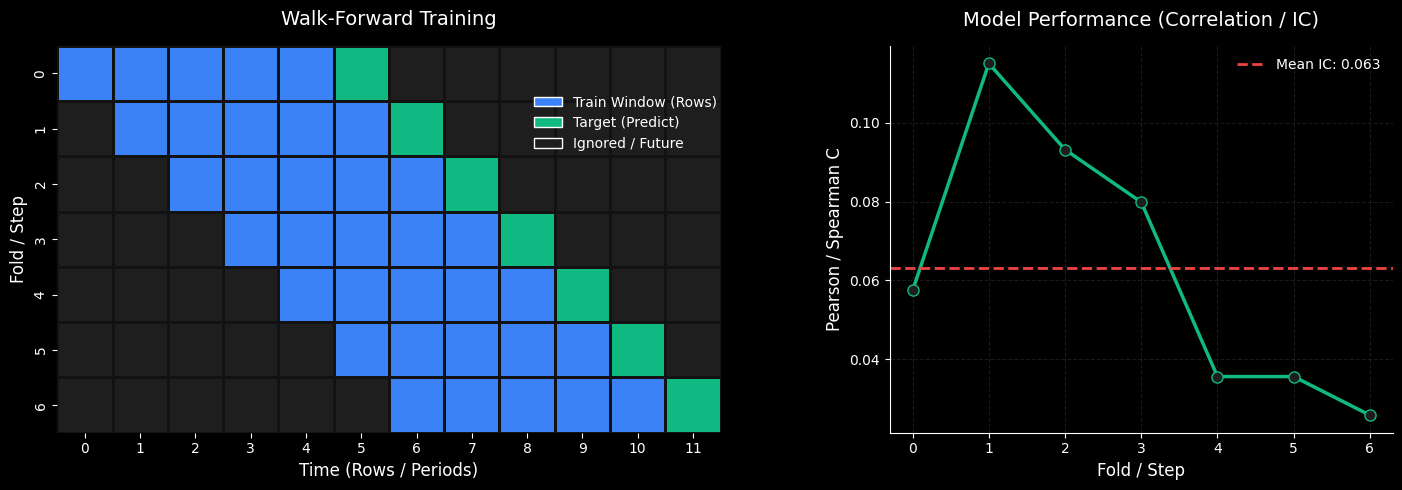

In [12]:
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from matplotlib.patches import Patch
except:
    pass

def visualize_walk_forward_concept():
    """
    Generates a CNN-like sliding window visualization of the walk-forward
    training process and the resulting Correlation (IC) over time.
    """
    plt.style.use('dark_background')

    n_periods = 12
    train_window = 5
    folds = n_periods - train_window
    grid = np.zeros((folds, n_periods))
    for i in range(folds):
        grid[i, i:i+train_window] = 1
        grid[i, i+train_window] = 2

    np.random.seed(42)
    simulated_ic = np.random.uniform(0.02, 0.12, size=folds)

    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(15, 5),
        gridspec_kw={'width_ratios': [2.5, 1.5]}
    )

    cmap = sns.color_palette(['#1e1e1e', '#3b82f6', '#10b981'])
    sns.heatmap(grid, cmap=cmap, linewidths=2, linecolor='#121212',
                ax=ax1, cbar=False, square=True)

    ax1.set_title('Walk-Forward Training', fontsize=14, pad=15)
    ax1.set_xlabel('Time (Rows / Periods)', fontsize=12)
    ax1.set_ylabel('Fold / Step', fontsize=12)

    legend_elements = [
        Patch(facecolor='#3b82f6', edgecolor='w', label='Train Window (Rows)'),
        Patch(facecolor='#10b981', edgecolor='w', label='Target (Predict)'),
        Patch(facecolor='#1e1e1e', edgecolor='w', label='Ignored / Future')
    ]
    ax1.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(0.7, 0.8), frameon=False)

    ax2.plot(range(folds), simulated_ic, marker='o', color='#10b981',
             linewidth=2.5, markersize=8, markerfacecolor='#1e1e1e')

    mean_ic = np.mean(simulated_ic)
    ax2.axhline(mean_ic, color='#ef4444', linestyle='--', linewidth=2,
                label=f'Mean IC: {mean_ic:.3f}')

    ax2.set_title('Model Performance (Correlation / IC)', fontsize=14, pad=15)
    ax2.set_xlabel('Fold / Step', fontsize=12)
    ax2.set_ylabel('Pearson / Spearman C', fontsize=12)
    ax2.set_xticks(range(folds))
    ax2.grid(True, color='#333333', linestyle='--', alpha=0.5)
    ax2.legend(frameon=False)

    sns.despine(ax=ax2)
    plt.tight_layout()
    plt.show()

visualize_walk_forward_concept()

# Key Code

In [10]:
# INSTALL
!pip install -q --upgrade tabpfn tabpfn-client xgboost optuna pyarrow


In [4]:
# IMPORTS, DEVICE, SECRETS
try:
    import os
    import time
    import warnings
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from scipy.stats import norm
except:
    pass

try:
    import torch
    if torch.cuda.is_available():
        DEVICE = "cuda"
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        DEVICE = "mps"  # Mac GPU
    else:
        DEVICE = "cpu"
except ImportError:
    DEVICE = "cpu"

# ---- secrets ----
TABPFN_API_TOKEN = ""   # tabpfn_client token.

"""
To get a TabPFN token, one option is to run

"import tabpfn_client; tabpfn_client.get_access_token()"

This may open a browser login, then paste the returned string above.
This is needed if set TABPFN_BACKEND="api" below.

"""

TABPFN_TOKEN = ""       # for TABPFN_BACKEND="local": a one-time license acceptance is
                        # required even for LOCAL inference now. Get a free API key from
                        # https://ux.priorlabs.ai/account (register/log in, accept the
                        # license on the Licenses tab), paste it here. Without this,
                        # TabPFNRegressor.fit() raises TabPFNLicenseError in any
                        # non-interactive environment.

                        # This can be the same as TABPFN_API_TOKEN

HF_TOKEN = ""           # Differs from the above two.
                        # needed for TABPFN_BACKEND="local" if your account's
                        # TabPFN checkpoint download requires Hugging Face auth.

if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
if TABPFN_TOKEN:
    os.environ["TABPFN_TOKEN"] = TABPFN_TOKEN
os.environ.setdefault("TABPFN_MODEL_CACHE_DIR", "./tabpfn_cache")  # local folder, not Drive

if TABPFN_API_TOKEN:
    import tabpfn_client
    tabpfn_client.set_access_token(TABPFN_API_TOKEN)

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)

In [5]:
# Configuration
# Every dataset-specific choice lives here.
# Edit this cell and the RUN cell to point the engine at your own panel

CFG = {
    # ---- data source ----
    # Path to  panel file: .csv, .parquet, .feather, or .fthr.
    # Leave blank ("") to run synthetic self-check.
    "DATA_PATH": "",

    # Column names in your panel -- edit to match your schema.
    # simply run smth like df = load_panel(CFG["DATA_PATH"] print(df.columns) to check
    "TIME_COL":    "date",      # any sortable, hashable period key: month, week, date, int index...
    "ENTITY_COL":  "permno",    # asset/stock/coin identifier
    "RETURN_COL":  "return",    # the CONTEMPORANEOUS return for that (entity, time) -- the
                                # engine builds the forward target from this itself; do not
                                # pre-shift it yourself.
    "FEATURE_COLS": None,       # list of predictor columns, or None to auto-use every column
                                # except the ones named elsewhere in this dict.


    "CONTEMP_COL": None,        # optional: a  same-period column to
                                # check that Gate 2 (below) can detect a leak.
                                # Leave None to skip that check.

    "SIZE_COL": None,           # optional: the market-cap / volume-style COLUMN for a liquidity
                                # filter. Leave None to skip filtering entirely.
    "DROP_MICRO_CAPS": False,   # set True (and give SIZE_COL) to drop the bottom decile(s).
    "LIQ_DECILE_CUTOFF": 2,     # drop the bottom N size-deciles each period, if the above two are on.

    # ---- target construction ----
    "HORIZON": 1,   # predict the return this many periods ahead
    "BUFFER": 0,    # extra periods of delay before that (e.g. 1 for reporting-lag accounting data)
    # forward target = the return recorded (HORIZON + BUFFER) POSITIONS later in the sorted

    # This is done by:
    # listing unique time keys in your data and not a naive .shift(), which may
    # misalign on a panel with gaps.

    # ---- walk-forward ----
    "TRAIN_WINDOW": 60,    # rolling training window, in periods (whatever TIME_COL's unit is)
    "MIN_ENTITIES": 50,    # skip a fold if fewer than this many entities are usable

    # ---- models / tuning ----
    "TABPFN_BACKEND": "local",   # "local" (tabpfn pkg: your GPU/CPU, downloads weights once) or
                                 # "api" (tabpfn_client pkg: cloud call, needs TABPFN_API_TOKEN)
    "TABPFN_MAX_TRAIN": 12000,   # TabPFN only ever sees a random subsample of the training
                                 # window up to this many rows. Also used by "_capped" variants.
    "TABPFN_N_ESTIMATORS": 4,    # Number of ensemble members; higher = more robust.
                                 # Training time scales linearly
    "TABPFN_OUTPUT": "mean",     # "mean" or "median"

    "RETUNE_EVERY": 60,          # re-run Optuna every this-many folds; re-use the last found
                                 # params for folds in between (because re-tuning every fold is not
                                 # affordable over hundreds of folds).

                                 # BO = Bayesian Optimisation
    "BO_TRIALS": 40,             # number of hyperparameter combinations to test when tuning
    "BO_EPSILON": 0.15,          # epsilon-greedy: this fraction of trials sample uniformly at
                                 # random instead of following the TPE (Tree-structured Parzen Estimator)
                                 # surrogate, and this
                                 # fraction of prune checks get bypassed -- keeps tuning from
                                 # committing early to a noisy local optimum found from few folds.
    "BO_TURNOVER_PENALTY": 0,    # tuning objective = median(IC) - penalty * mean(turnover)
                                 # Daniel used 0.05 for his trials, which is perhaps insignificant.
    "IMPUTER_STRATEGY": "median",# for ElasticNet/OLS only -- XGBoost and TabPFN take raw NaNs.

    # ---- reporting ----
    "PERIODS_PER_YEAR": 12,   # 12 monthly, 52 weekly, 252 daily, 4 quarterly...
    "EXPERIMENT_LABEL": "",   # optional tag written into every logged row, so multiple runs'
                              # logs can later be concatenated and compared by this tag.

    # ---- I/O ----
    "LOG_PATH": "./wf_results_log.csv",
    "IMPORTANCE_PATH": "./wf_feature_importance.csv",  # set to None to skip logging importances
    "FLUSH_EVERY": 12,  # write buffered rows to LOG_PATH every this-many folds
}


def xgb_space(trial):
    return {
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
    }


def enet_space(trial):
    return {
        "alpha": trial.suggest_float("alpha", 1e-4, 1.0, log=True),
        "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
    }


# Which model NAMES get tuned, and with what search space. A name not in this dict
# (e.g. "XGBoost_default", or any "_capped" variant) is never tuned directly.

# NB: capped variants re-use their base model's tuned params,
# which isolates the effect of "more rows".
TUNING_SPACES = {
    "XGBoost": xgb_space,
    "ElasticNet": enet_space,
}


In [6]:
# BUILDING BLOCKS: generic loader, portfolio math, model factory

def load_panel(path):
    ext = path.lower().rsplit(".", 1)[-1]
    if ext == "csv":
        return pd.read_csv(path)
    if ext == "parquet":
        return pd.read_parquet(path)
    if ext in ("feather", "fthr"):
        return pd.read_feather(path)
    raise ValueError(f"Unrecognised extension '.{ext}' for {path}; expected csv/parquet/feather/fthr.")


def gaussian_rank_weights(pct_ranks, clip=3.0):
    # pct_ranks: cross-sectional percentile rank in (0,1). Returns dollar-neutral,
    # gross-exposure-one weights via a clipped inverse-normal (Gaussian rank) transform.
    z = np.clip(norm.ppf(np.clip(pct_ranks, 1e-4, 1 - 1e-4)), -clip, clip)
    denom = np.abs(z).sum()
    return z / denom if denom > 0 else np.zeros_like(z)


def turnover(w_new, entities_new, w_old, entities_old):
    # One-way TO = 1/2 * sum |w_new - w_old|
    # an entity absent from one side contributes its full weight on the other.
    # w_old is None on the first fold for a given model -> returns 1.0
    # "resumed" flag should prevent turnover spike if resume training after t0
    if w_old is None:
        return 1.0
    s_old = pd.Series(w_old, index=entities_old)
    s_new = pd.Series(w_new, index=entities_new)
    aligned = pd.concat([s_old, s_new], axis=1).fillna(0.0)
    return 0.5 * (aligned.iloc[:, 1] - aligned.iloc[:, 0]).abs().sum()


class TabPFNWrapper:
    # Define a sklearn-style fit/predict wrapper
    #
    # backend="local": tabpfn package, runs on DEVICE, needs the model weights (auto-
    #     downloaded from Hugging Face the first time; set HF_TOKEN above if that
    #     download needs auth).
    # backend="api": tabpfn_client package, calls Prior Labs' hosted API, no download,
    #     needs TABPFN_API_TOKEN above. Lighter -- good for the self-check below, or
    #     for anyone without local GPU access.

    def __init__(self, max_train, n_estimators, output_type="mean", backend="local", random_state=42):
        self.max_train = max_train
        self.n_estimators = n_estimators
        self.output_type = output_type
        self.backend = backend
        self.random_state = random_state
        self._m = None

    def fit(self, X, y):
        if len(X) > self.max_train:
            rng = np.random.RandomState(self.random_state)
            idx = rng.choice(len(X), self.max_train, replace=False)
            X, y = X[idx], y[idx]
        if self.backend == "api":
            from tabpfn_client import TabPFNRegressor
            self._m = TabPFNRegressor()
        else:
            from tabpfn import TabPFNRegressor
            self._m = TabPFNRegressor(
                device=DEVICE, n_estimators=self.n_estimators,
                ignore_pretraining_limits=True, random_state=self.random_state,
            )
        self._m.fit(X, y)
        return self

    def predict(self, X):
        try:
            return self._m.predict(X, output_type=self.output_type)
        except TypeError:
            return self._m.predict(X)


def build_model(name, cfg, params=None):
    # name may carry a "_capped" or "_default" suffix; the base name (before the
    # first underscore) selects the model class. build_model() doesn't know or care
    # about the suffix -- row-capping and tuned-vs-default params are handled by the
    # caller (WalkForwardBacktester.run).
    from sklearn.linear_model import ElasticNet, LinearRegression
    from sklearn.impute import SimpleImputer
    from sklearn.pipeline import make_pipeline
    from xgboost import XGBRegressor

    params = params or {}
    base = name.split("_")[0]
    imputer_strategy = cfg.get("IMPUTER_STRATEGY")

    if base == "OLS":
        steps = [SimpleImputer(strategy=imputer_strategy)] if imputer_strategy else []
        return make_pipeline(*steps, LinearRegression())

    if base == "ElasticNet":
        steps = [SimpleImputer(strategy=imputer_strategy)] if imputer_strategy else []
        return make_pipeline(*steps, ElasticNet(max_iter=20000, random_state=42, **params))

    if base == "XGBoost":
        defaults = dict(n_estimators=300, random_state=42, n_jobs=-1)  # native NaN handling
        defaults.update(params)
        return XGBRegressor(**defaults)

    if base == "TabPFN":
        return TabPFNWrapper(
            max_train=cfg["TABPFN_MAX_TRAIN"], n_estimators=cfg["TABPFN_N_ESTIMATORS"],
            output_type=cfg["TABPFN_OUTPUT"], backend=cfg["TABPFN_BACKEND"],
        )

    raise ValueError(f"No builder for base model '{base}' (from name '{name}'). "
                      f"Add a branch to build_model() for any new model type.")


In [7]:
# THE ENGINE
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


class EpsilonGreedySampler(optuna.samplers.BaseSampler):
    """
    Wraps a TPE sampler: with probability epsilon, sample this parameter uniformly
    at random instead of following the surrogate model. Keeps Optuna from
    committing early to a spuriously-good local optimum found from very few
    trials/CV folds
    """
    def __init__(self, base_sampler, epsilon=0.15, seed=42):
        self.base = base_sampler
        self.random = optuna.samplers.RandomSampler(seed=seed)
        self.epsilon = epsilon
        self._rng = np.random.RandomState(seed)

    def infer_relative_search_space(self, study, trial):
        return self.base.infer_relative_search_space(study, trial)

    def sample_relative(self, study, trial, search_space):
        if self._rng.rand() < self.epsilon:
            return {}  # defer every param to sample_independent below
        return self.base.sample_relative(study, trial, search_space)

    def sample_independent(self, study, trial, param_name, param_distribution):
        if self._rng.rand() < self.epsilon:
            return self.random.sample_independent(study, trial, param_name, param_distribution)
        return self.base.sample_independent(study, trial, param_name, param_distribution)


class WalkForwardBacktester:
    def __init__(self, df, cfg):
        self.cfg = cfg
        self.time_col = cfg["TIME_COL"]
        self.entity_col = cfg["ENTITY_COL"]
        self.return_col = cfg["RETURN_COL"]
        self.contemp_col = cfg.get("CONTEMP_COL")
        self.size_col = cfg.get("SIZE_COL")
        self.feature_cols = cfg.get("FEATURE_COLS")
        self.df = df.copy()
        self._prepare_data()

    # ---------------- target construction ----------------
    def _prepare_data(self):
        df = self.df
        cfg = self.cfg
        K = cfg["HORIZON"] + cfg["BUFFER"]

        # position-based calendar join: the forward period is the time-key sitting K
        # positions later in the SORTED list of unique time keys present in the data --
        # not `.shift(K)`, which silently misaligns on any panel with gaps (a missing
        # period for one entity shifts everyone else's target on a naive shift()).
        times = sorted(df[self.time_col].unique())
        pos = {t: i for i, t in enumerate(times)}
        fwd_of = {t: times[i + K] for t, i in pos.items() if i + K < len(times)}
        df["_fwd_time_key"] = df[self.time_col].map(fwd_of)

        fwd_returns = (
            df[[self.entity_col, self.time_col, self.return_col]]
            .rename(columns={self.time_col: "_fwd_time_key", self.return_col: "_fwd_ret"})
        )
        df = df.merge(fwd_returns, on=[self.entity_col, "_fwd_time_key"], how="left")

        if self.size_col and cfg.get("DROP_MICRO_CAPS"):
            cutoff = cfg.get("LIQ_DECILE_CUTOFF", 2)
            def _drop_bottom(g):
                thresh = g[self.size_col].quantile(cutoff / 10.0)
                return g[g[self.size_col] > thresh]
            df = df.groupby(self.time_col, group_keys=False).apply(_drop_bottom)
        elif self.size_col is None and cfg.get("DROP_MICRO_CAPS"):
            import warnings
            warnings.warn("DROP_MICRO_CAPS is set but SIZE_COL is None -- skipping the liquidity filter.")

        # cross-sectional percentile rank of the forward return, within the period
        # being predicted FOR (not the period being predicted FROM).
        df["_target_rank"] = df.groupby("_fwd_time_key")["_fwd_ret"].rank(pct=True)

        if self.feature_cols is None:
            reserved = {self.time_col, self.entity_col, self.return_col, self.contemp_col,
                        self.size_col, "_fwd_time_key", "_fwd_ret", "_target_rank"}
            self.feature_cols = [c for c in df.columns if c not in reserved]

        self.df = df.dropna(subset=["_target_rank"]).reset_index(drop=True)
        self.times = sorted(self.df[self.time_col].unique())
        self._run_gates()

    # ---------------- sanity gates ----------------
    def _run_gates(self):
        df, cfg = self.df, self.cfg
        K = cfg["HORIZON"] + cfg["BUFFER"]
        times = self.times
        pos = {t: i for i, t in enumerate(times)}

        # GATE 1 -- target alignment. Independently recompute the forward return for a
        # random sample of rows via a fresh, separate lookup and check it matches
        # "_fwd_ret". Catches an off-by-one or merge-key bug in _prepare_data.
        lookup = (df[[self.entity_col, self.time_col, self.return_col]]
                  .drop_duplicates([self.entity_col, self.time_col])
                  .set_index([self.entity_col, self.time_col])[self.return_col])
        sample = df.sample(min(400, len(df)), random_state=0)
        checked = matches = 0
        for _, row in sample.iterrows():
            i = pos.get(row[self.time_col])
            if i is None or i + K >= len(times):
                continue
            key = (row[self.entity_col], times[i + K])
            if key in lookup.index:
                checked += 1
                if np.isclose(lookup.loc[key], row["_fwd_ret"], equal_nan=True):
                    matches += 1
        if checked:
            status = "PASS" if matches == checked else "FAIL -- investigate before trusting results"
            print(f"GATE 1 (target alignment): {matches}/{checked} sampled rows match return at t+{K} -- {status}")
        else:
            print("GATE 1 (target alignment): no rows had a checkable t+K neighbour in this sample.")

        # GATE 2 -- leak probe. Only runs if you supplied CONTEMP_COL: confirms the
        # harness CAN detect an obvious leak (predicting from a genuinely same-period
        # column should look artificially good), as a check on the gate itself.
        # only takes one column - one could easily extend to a multi reg
        if self.contemp_col:
            from sklearn.linear_model import LinearRegression
            probe = df[[self.contemp_col]].fillna(0.0).values
            m = LinearRegression().fit(probe, df["_target_rank"].values)
            r2 = m.score(probe, df["_target_rank"].values)
            verdict = "looks leaky, as expected for a same-period column" if r2 > 0.3 else "no obvious leak signature"
            print(f"GATE 2 (leak probe on '{self.contemp_col}'): R^2={r2:.3f} ({verdict})")
        else:
            print("GATE 2 (leak probe): skipped -- no CONTEMP_COL configured.")

        # GATE 3 -- no NaNs in the target. NaN FEATURES are fine (XGBoost/TabPFN take
        # them natively; ElasticNet/OLS get a per-fold-fit imputer).
        n_nan_target = df["_target_rank"].isna().sum()
        print(f"GATE 3 (target NaNs): {n_nan_target} -- {'PASS' if n_nan_target == 0 else 'FAIL'}")

    # ---------------- hyperparameter tuning ----------------
    def _tune(self, base, Xtr, ytr, times_tr, ents_tr, space_fn):
        cfg = self.cfg
        epsilon = cfg.get("BO_EPSILON", 0.15)
        rng = np.random.RandomState(42)
        uniq_t = sorted(pd.unique(times_tr))
        n_cv = min(6, max(2, len(uniq_t) // 4))
        cv_points = uniq_t[-n_cv:]

        def objective(trial):
            params = space_fn(trial)
            ics, tos, prev = [], [], None
            for k, cv_t in enumerate(cv_points):
                tr_m = times_tr < cv_t
                te_m = times_tr == cv_t
                if tr_m.sum() < 30 or te_m.sum() < 10:
                    continue
                m = build_model(base, cfg, params)
                m.fit(Xtr[tr_m], ytr[tr_m])
                p = m.predict(Xtr[te_m])
                ic = pd.Series(p).corr(pd.Series(ytr[te_m]), method="spearman")
                w = gaussian_rank_weights(pd.Series(p).rank(pct=True).values)
                to = turnover(w, ents_tr[te_m], *(prev or (None, None)))
                prev = (w, ents_tr[te_m])
                ics.append(-1.0 if np.isnan(ic) else ic)
                tos.append(to)

                partial = float(np.median(ics) - cfg.get("BO_TURNOVER_PENALTY", 0.05) * np.mean(tos))
                trial.report(partial, step=k)
                if trial.should_prune() and rng.rand() >= epsilon:
                    raise optuna.TrialPruned()

            if not ics:
                return -999.0
            return float(np.median(ics) - cfg.get("BO_TURNOVER_PENALTY", 0.05) * np.mean(tos))

        sampler = EpsilonGreedySampler(optuna.samplers.TPESampler(seed=42), epsilon=epsilon, seed=42)
        study = optuna.create_study(direction="maximize", sampler=sampler, pruner=optuna.pruners.MedianPruner())
        study.optimize(objective, n_trials=cfg.get("BO_TRIALS", 40), show_progress_bar=False)
        return study.best_params

    # ---------------- walk-forward loop ----------------
    def run(self, models_to_run, tuning_spaces=None, log_path=None, importance_path=None):
        cfg = self.cfg
        df = self.df
        tuning_spaces = tuning_spaces or {}
        log_path = log_path or cfg["LOG_PATH"]
        importance_path = cfg.get("IMPORTANCE_PATH") if importance_path is None else importance_path

        times = self.times
        W = cfg["TRAIN_WINDOW"]
        min_entities = cfg.get("MIN_ENTITIES", 30)
        retune_every = cfg.get("RETUNE_EVERY", W)

        X_ALL = df[self.feature_cols].values.astype(float)
        Y_RANK = df["_target_rank"].values.astype(float)
        Y_RET = df["_fwd_ret"].values.astype(float)
        ENT_ALL = df[self.entity_col].values
        TIME_ALL = df[self.time_col].values
        time_to_rows = df.groupby(self.time_col).indices  # {time_key: row-position array}

        fields = ["ym", "model", "ic", "turnover", "gross_ret", "n_stocks", "tuned", "resumed"]
        if cfg.get("EXPERIMENT_LABEL"):
            fields = fields + ["experiment"]

        done = set()
        if os.path.exists(log_path):
            prior = pd.read_csv(log_path)
            # prior["ym"] comes back from CSV as a string even if the in-memory time key
            # is a pd.Period/Timestamp/etc -- compare both sides as strings.
            # Otherwise, "resuming" reruns + duplicates every row instead
            # of skipping what's already done.

            # Basically, because when we extra too csv we change how date is written
            done = set(zip(prior["ym"].astype(str), prior["model"]))
            print(f"resuming: {len(prior)} rows already on disk")

        rows, prev_weights, tuned_params = [], {}, {}
        n_folds = len(times) - W
        t0 = time.time()

        for i, t in enumerate(times):
            if i < W:
                continue
            window_times = times[max(0, i - W):i]
            tr_idx = (np.concatenate([time_to_rows[wt] for wt in window_times])
                      if window_times else np.array([], dtype=int))
            te_idx = time_to_rows[t]
            if len(te_idx) < min_entities or len(tr_idx) < min_entities:
                continue

            do_tune = (i % retune_every == 0)
            if i % cfg.get("PROGRESS_EVERY", 5) == 0:
                elapsed = time.time() - t0
                done_folds = i - W
                rate = done_folds / elapsed if elapsed > 0 and done_folds > 0 else None
                eta = f", ~{(n_folds - done_folds) / rate:.0f}s to go" if rate else ""
                tune_flag = " (retuning this fold)" if do_tune else ""
                print(f"fold {done_folds + 1}/{n_folds} -- period {t} -- {elapsed:.0f}s elapsed{eta}{tune_flag}")

            for model_name in models_to_run:
                if (str(t), model_name) in done:
                    continue
                base = model_name.split("_")[0]
                is_capped = model_name.endswith("_capped")
                was_cold_start = model_name not in prev_weights

                # -> "resumed": no prior weight vector this session sets turnover to 1.0.

                if base == "CoinFlip":
                    rng = np.random.RandomState((i * 2654435761 + hash(model_name)) % (2**31))
                    preds = rng.normal(size=len(te_idx))
                else:
                    Xtr, ytr = X_ALL[tr_idx], Y_RANK[tr_idx]
                    if is_capped and len(Xtr) > cfg["TABPFN_MAX_TRAIN"]:
                        rng = np.random.RandomState(42)
                        sub = rng.choice(len(Xtr), cfg["TABPFN_MAX_TRAIN"], replace=False)
                        Xtr, ytr = Xtr[sub], ytr[sub]

                    if do_tune and model_name in tuning_spaces:
                        tuned_params[model_name] = self._tune(
                            base, Xtr, ytr, TIME_ALL[tr_idx], ENT_ALL[tr_idx], tuning_spaces[model_name]
                        )
                    params = tuned_params.get(model_name, tuned_params.get(base, {}))

                    model = build_model(model_name, cfg, params)
                    model.fit(Xtr, ytr)
                    preds = model.predict(X_ALL[te_idx])

                    if importance_path and hasattr(model, "feature_importances_"):
                        self._log_importance(importance_path, t, model_name, model.feature_importances_)

                ic = pd.Series(preds).corr(pd.Series(Y_RANK[te_idx]), method="spearman")
                w = gaussian_rank_weights(pd.Series(preds).rank(pct=True).values)
                ents = ENT_ALL[te_idx]
                to = turnover(w, ents, *prev_weights.get(model_name, (None, None)))
                prev_weights[model_name] = (w, ents)
                gross = float(np.nansum(w * Y_RET[te_idx]))

                row = {"ym": t, "model": model_name, "ic": ic, "turnover": to,
                       "gross_ret": gross, "n_stocks": len(te_idx),
                       "tuned": int(do_tune and model_name in tuning_spaces),
                       "resumed": int(was_cold_start)}
                if cfg.get("EXPERIMENT_LABEL"):
                    row["experiment"] = cfg["EXPERIMENT_LABEL"]
                rows.append(row)

            if rows and i % cfg.get("FLUSH_EVERY", 12) == 0:
                self._flush(rows, log_path, fields)
                rows = []

        if rows:
            self._flush(rows, log_path, fields)
        print(f"done -- results in {log_path}")

    def _flush(self, rows, log_path, fields):
        new_df = pd.DataFrame(rows)[fields]
        header = not os.path.exists(log_path)
        new_df.to_csv(log_path, mode="a", header=header, index=False)

    def _log_importance(self, path, t, model_name, importances):
        row = {"ym": t, "model": model_name, **dict(zip(self.feature_cols, importances))}
        header = not os.path.exists(path)
        pd.DataFrame([row]).to_csv(path, mode="a", header=header, index=False)


ModuleNotFoundError: No module named 'optuna'

In [16]:
# REPORTING

def tear_sheet(log_path, periods_per_year=12, turnover_cost_bps=None):
    r = pd.read_csv(log_path)
    clean = r[r["resumed"] == 0]  # drop cold-start turnover=1.0 rows from turnover stats
    models = sorted(r["model"].unique())  # any model name you add to models_to_run shows up here.

    out = []
    for m in models:
        g = r[r["model"] == m]
        gc = clean[clean["model"] == m]
        ic = g["ic"].dropna()
        sd_ic = ic.std()
        nan_ic_pct = g["ic"].isna().mean() * 100
        # Flags flat predictions from models in output

        out.append({
            "model": m,
            "ave_ic": ic.mean(), "med_ic": ic.median(), "sd_ic": sd_ic,
            "IR": ic.mean() / sd_ic if sd_ic else np.nan,
            "hit_pct": (ic > 0).mean() * 100,
            "nan_ic_pct": nan_ic_pct,
            "ave_turnover": gc["turnover"].mean(),
            "gross_pct_yr": g["gross_ret"].mean() * periods_per_year * 100,
            "sharpe": (g["gross_ret"].mean() / g["gross_ret"].std() * np.sqrt(periods_per_year)
                       if g["gross_ret"].std() else np.nan),
        })
    table = pd.DataFrame(out).set_index("model").sort_values("ave_ic", ascending=False)
    print(table.round(4))
    if (table["nan_ic_pct"] > 0).any():
        print("\n(nan_ic_pct > 0 means that model predicted a near-constant value on some "
              "folds -- worth a look at whatever tuned/default params it used there)")

    if turnover_cost_bps:
        print("\nnet return (%/yr) at various cost/unit-turnover levels:")
        for bps in turnover_cost_bps:
            net = {m: (r.loc[r["model"] == m, "gross_ret"] - r.loc[r["model"] == m, "turnover"] * bps / 10000).mean()
                   * periods_per_year * 100 for m in models}
            print(f"  {bps:4d} bps:", {k: round(v, 2) for k, v in net.items()})

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    for m in models:
        g = r[r["model"] == m].sort_values("ym")
        ax[0].plot(range(len(g)), g["ic"].cumsum(), label=m)
    ax[0].set_title("cumulative rank IC")
    ax[0].legend(fontsize=7)
    for m in models:
        gc = clean[clean["model"] == m].sort_values("ym")
        ax[1].plot(range(len(gc)), gc["turnover"].rolling(12, min_periods=1).mean(), label=m)
    ax[1].set_title("turnover (12-period moving average)")
    ax[1].legend(fontsize=7)
    plt.tight_layout()
    plt.show()
    return table


## Run

Edit `CFG` in Cell 3 (data path, column names, horizon/buffer, backend) and the
`models_to_run` list below, then run this cell. `models_to_run` can be any mix of
`CoinFlip`, `OLS`, `ElasticNet`, `XGBoost`, `TabPFN`, and a `_capped` or `_default`
suffixed variant of any of them (e.g. `XGBoost_capped` re-fits XGBoost on a
row-capped subsample using the SAME tuned hyperparameters as `XGBoost`, for an
apples-to-apples comparison against TabPFN's row budget; `XGBoost_default` skips
Optuna entirely and just uses the class defaults).

To run new models, append to list here, and also at build_model(name, cfg, params=None)

In [19]:
# RUN
"""
assert CFG["DATA_PATH"], "set CFG['DATA_PATH'] in Cell 3 first"
df = load_panel(CFG["DATA_PATH"])
bt = WalkForwardBacktester(df, CFG)
models_to_run = ["CoinFlip", "OLS", "ElasticNet", "XGBoost", "XGBoost_capped", "TabPFN"]
bt.run(models_to_run, tuning_spaces=TUNING_SPACES)
tear_sheet(CFG["LOG_PATH"], periods_per_year=CFG["PERIODS_PER_YEAR"],
          turnover_cost_bps=[0, 50, 100, 200])
"""

GATE 1 (target alignment): 395/395 sampled rows match return at t+1 -- PASS
GATE 2 (leak probe): skipped -- no CONTEMP_COL configured.
GATE 3 (target NaNs): 0 -- PASS
resuming: 245 rows already on disk
fold 1/467 -- period 19820131.0 -- 0s elapsed (retuning this fold)
fold 6/467 -- period 19820630.0 -- 0s elapsed, ~0s to go
fold 11/467 -- period 19821130.0 -- 0s elapsed, ~0s to go
fold 16/467 -- period 19830430.0 -- 0s elapsed, ~0s to go
fold 21/467 -- period 19830930.0 -- 0s elapsed, ~0s to go
fold 26/467 -- period 19840229.0 -- 0s elapsed, ~0s to go
fold 31/467 -- period 19840731.0 -- 0s elapsed, ~0s to go
fold 36/467 -- period 19841231.0 -- 0s elapsed, ~0s to go
fold 41/467 -- period 19850531.0 -- 0s elapsed, ~0s to go
fold 46/467 -- period 19851031.0 -- 0s elapsed, ~0s to go
fold 51/467 -- period 19860331.0 -- 12s elapsed, ~104s to go


KeyboardInterrupt: 

## Self-check

No files needed -- generates a small synthetic panel with a planted, laggy
feature-to-return signal, then runs the full engine on it: target construction, both gates, the walk-forward loop, and the tear sheet. `TabPFN` is included via
`TABPFN_BACKEND="api"`. Every non-CoinFlip model should show clearly positive
IC; if one doesn't, or a gate fails, something upstream is broken.

*   **Fixed Seed:** It initializes with `seed=0` to ensure complete reproducibility every time the self-check runs.
*   **The Hidden Model ($\beta$):** It creates an array of true underlying weights (`true_beta`). This is the mathematical "alpha" the machine learning models will attempt to discover.
*   **The Features ($X$):** It generates normally distributed random data for 60 entities across 40 time periods.



$$R_t = 0.05(X_{t-1} \cdot \beta) + \epsilon$$



---


Then flatten the matrices into a tabular Pandas DataFrame and intentionally injects complications to test the pipeline's robustness:

*   **`contemp_flag`:** It creates a column that is an exact 1-to-1 copy of the current period's return. This is deliberate bait to ensure the time-shifting logic works and that same-period data does not leak into the features.
*   **NaNs:** It randomly deletes roughly 5% of the feature data. This tests whether the pipeline's imputation logic (and native NaN handling for models like XGBoost) functions correctly without crashing.

GATE 1 (target alignment): 388/388 sampled rows match return at t+1 -- PASS
GATE 2 (leak probe on 'contemp_flag'): R^2=0.000 (no obvious leak signature)
GATE 3 (target NaNs): 0 -- PASS
TABPFN_API_TOKEN is blank in Cell 2 -- skipping TabPFN in the self-check (set it there to include a live API ping).
fold 1/24 -- period 15 -- 0s elapsed (retuning this fold)
fold 6/24 -- period 20 -- 2s elapsed, ~6s to go
fold 11/24 -- period 25 -- 2s elapsed, ~3s to go
fold 16/24 -- period 30 -- 3s elapsed, ~2s to go (retuning this fold)
fold 21/24 -- period 35 -- 4s elapsed, ~1s to go
done -- results in ./_selfcheck_log.csv
            ave_ic  med_ic   sd_ic      IR  hit_pct  nan_ic_pct  ave_turnover  gross_pct_yr  sharpe
model                                                                                              
ElasticNet  0.1999  0.1934  0.1378  1.4504  95.8333         0.0        0.7086      302.2355  5.2412
OLS         0.1999  0.1941  0.1381  1.4475  95.8333         0.0        0.7086      30

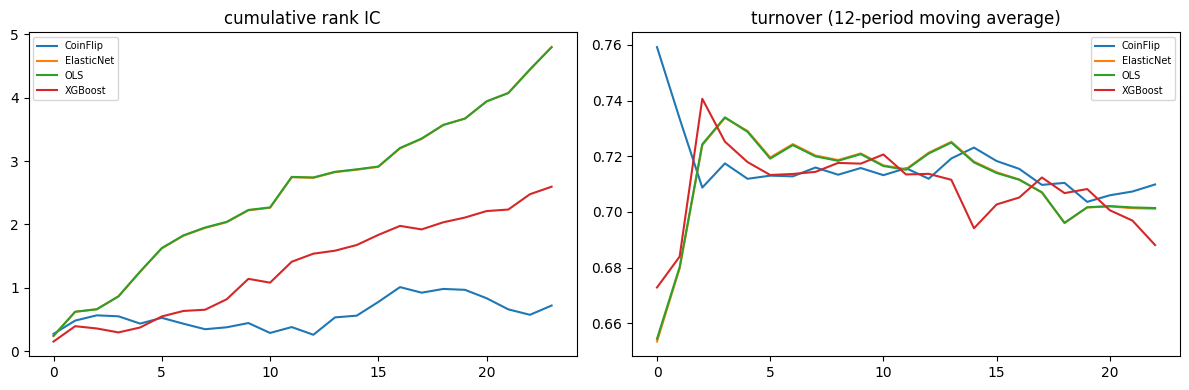


SELF-CHECK: PASS -- every real model beat zero IC on the planted signal


In [24]:
# SELF-CHECK
"""
def make_synthetic_panel(n_periods=40, n_entities=60, n_features=6, seed=0):
    rng = np.random.RandomState(seed)
    true_beta = rng.normal(size=n_features)
    X_by_t = {t: rng.normal(size=(n_entities, n_features)) for t in range(n_periods)}
    rows = []
    for t in range(n_periods):
        # return at t is driven by features one period EARLIER (t-1), so a model using
        # time-t features to predict the return at t+1 has real signal to find.
        signal = np.zeros(n_entities) if t == 0 else X_by_t[t - 1] @ true_beta
        ret = 0.05 * signal + rng.normal(scale=1.0, size=n_entities)
        for e in range(n_entities):
            row = {"time_id": t, "entity_id": e, "ret": ret[e], "contemp_flag": ret[e]}
            for j in range(n_features):
                row[f"f{j}"] = X_by_t[t][e, j]
            rows.append(row)
    df = pd.DataFrame(rows)
    feat_cols = [f"f{j}" for j in range(n_features)]
    mask = rng.rand(len(df), n_features) < 0.05  # sprinkle NaNs to exercise the imputer /
    for j, c in enumerate(feat_cols):             # native-NaN paths too
        df.loc[mask[:, j], c] = np.nan
    return df


_sc_df = make_synthetic_panel()
_sc_cfg = dict(CFG)  # copy -- do not touch the real CFG
_sc_cfg.update({
    "TIME_COL": "time_id", "ENTITY_COL": "entity_id", "RETURN_COL": "ret",
    "CONTEMP_COL": "contemp_flag", "SIZE_COL": None, "DROP_MICRO_CAPS": False,
    "FEATURE_COLS": [f"f{j}" for j in range(6)],
    "HORIZON": 1, "BUFFER": 0, "TRAIN_WINDOW": 15, "MIN_ENTITIES": 10,
    "BO_TRIALS": 5, "RETUNE_EVERY": 15,
    "TABPFN_BACKEND": "api", "TABPFN_MAX_TRAIN": 200, "TABPFN_N_ESTIMATORS": 2,
    "LOG_PATH": "./_selfcheck_log.csv", "IMPORTANCE_PATH": None, "EXPERIMENT_LABEL": "",
})
if os.path.exists(_sc_cfg["LOG_PATH"]):
    os.remove(_sc_cfg["LOG_PATH"])

_sc_bt = WalkForwardBacktester(_sc_df, _sc_cfg)

_sc_models = ["CoinFlip", "OLS", "ElasticNet", "XGBoost"]
if TABPFN_API_TOKEN:
    _sc_models.append("TabPFN")
else:
    print("TABPFN_API_TOKEN is blank in Cell 2 -- skipping TabPFN in the self-check "
          "(set it there to include a live API ping).")

try:
    _sc_bt.run(_sc_models, tuning_spaces=TUNING_SPACES)
    _sc_table = tear_sheet(_sc_cfg["LOG_PATH"], periods_per_year=_sc_cfg["PERIODS_PER_YEAR"])
    _real_models = [m for m in _sc_models if m != "CoinFlip"]
    _ok = (_sc_table.loc[_real_models, "ave_ic"] > 0).all()
    print("\nSELF-CHECK:", "PASS -- every real model beat zero IC on the planted signal" if _ok
          else "CHECK RESULTS ABOVE -- a model came in at/below zero IC on data with a known signal")
except Exception as e:
    print(f"SELF-CHECK FAILED: {type(e).__name__}: {e}")
"""

## Appendix -- compiled multi-experiment results

This is a narrow tool to take my own training done on seven experiments on three datasets in a simple form. This is not needed to run the above, and can be deleted.

A test case on any new software is pre. factset to replicate one of my experiments on the same dataset and see if ICS, returns etc. are similar.

Input: reads a long-format results CSV (one row per period/model/experiment, e.g. several `LOG_PATH` outputs concatenated with an `experiment`/`Experiment` tag column)
Output: comparison table grouped by experiment and model.

In [2]:
# APPENDIX

import pandas as pd
pd.set_option("display.width", 200)
try:
    from google.colab import files
    _uploaded = files.upload()
    _compiled_path = next(iter(_uploaded))
except ImportError:
    _compiled_path = input("Not running in Colab -- enter the path to your compiled results CSV: ").strip()

_compiled = pd.read_csv(_compiled_path)

def _resolve(df, *aliases):
    for a in aliases:
        for c in df.columns:
            if c.lower() == a.lower():
                return c
    return None

_c_model = _resolve(_compiled, "model")
_c_exp = _resolve(_compiled, "experiment")
_c_ic = _resolve(_compiled, "ic")
_c_to = _resolve(_compiled, "turnover")
_c_gross = _resolve(_compiled, "gross_ret")

# There's nothing in this particular file's columns (ym/Model/ic/.../Experiment) that says
# which experiment ran at which frequency, so this is NOT auto-detected -- a compiled file
# mixing e.g. monthly equity experiments with a weekly crypto one needs each annualized
# differently, or the weekly one's gross_pct_yr comes out ~4x too small.

# List any experiment that ISN'T monthly here by its exact Experiment label; anything not listed
# uses DEFAULT_PERIODS_PER_YEAR, and the print below tells you which rows that applied to.
PERIODS_PER_YEAR_BY_EXPERIMENT = {
    "Exp 7: Crypto Weekly": 52,
}
DEFAULT_PERIODS_PER_YEAR = 12

group_cols = [c for c in (_c_exp, _c_model) if c]
if not group_cols or _c_ic is None:
    print("Could not find a model/experiment/ic column in this file -- check its header:")
    print(list(_compiled.columns))
else:
    if _c_gross:
        if _c_exp:
            ppy = _compiled[_c_exp].map(PERIODS_PER_YEAR_BY_EXPERIMENT).fillna(DEFAULT_PERIODS_PER_YEAR)
        else:
            ppy = DEFAULT_PERIODS_PER_YEAR
        _compiled["_gross_pct_yr"] = _compiled[_c_gross] * ppy * 100

    agg = {"ave_ic": (_c_ic, "mean"), "med_ic": (_c_ic, "median"), "sd_ic": (_c_ic, "std"),
           "hit_pct": (_c_ic, lambda s: (s > 0).mean() * 100)}
    if _c_to:
        agg["ave_turnover"] = (_c_to, "mean")
    if _c_gross:
        agg["gross_pct_yr"] = ("_gross_pct_yr", "mean")
    summary = _compiled.groupby(group_cols).agg(**agg).round(4)
    print(summary)

    if _c_exp:
        unlisted = sorted(set(_compiled[_c_exp].dropna().unique()) - set(PERIODS_PER_YEAR_BY_EXPERIMENT))
        if unlisted:
            print(f"\n(annualized at the default {DEFAULT_PERIODS_PER_YEAR}/yr for: {unlisted} -- "
                  f"edit PERIODS_PER_YEAR_BY_EXPERIMENT above if any of these aren't monthly)")

Saving compiled_experiment_results_FULL (1).csv to compiled_experiment_results_FULL (1) (1).csv
                                                   ave_ic  med_ic   sd_ic  hit_pct  ave_turnover  gross_pct_yr
Experiment                      Model                                                                         
Exp 1: Baseline (12k, n=4)      CoinFlip          -0.0010 -0.0010  0.0153  46.3636        0.7130       -0.0934
                                ElasticNet         0.0854  0.0816  0.1451  71.5909        0.1531        7.4524
                                ElasticNet_capped  0.0804  0.0748  0.1382  71.1364        0.2893        6.9081
                                TabPFN             0.0841  0.0757  0.1492  73.6364        0.2882        6.5327
                                XGBoost            0.0930  0.0974  0.1268  79.5455        0.2266        9.7223
                                XGBoost_capped     0.0706  0.0659  0.1030  78.1818        0.4826        7.0994
Exp 2: Ensemble 

In [19]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

df_base = summary.reset_index().dropna(subset=['Experiment', 'Model'])
df_base = df_base[~df_base["Experiment"].str.contains("Exp 4")]

exp1_sub = df_base[df_base['Experiment'].str.contains("Baseline")]
base_ic_ref = exp1_sub[exp1_sub['Model'].isin(["XGBoost", "ElasticNet"])]['ave_ic'].mean()
base_to_ref = exp1_sub[exp1_sub['Model'].isin(["XGBoost", "ElasticNet"])]['ave_turnover'].mean()
base_ret_ref = exp1_sub[exp1_sub['Model'].isin(["XGBoost", "ElasticNet"])]['gross_pct_yr'].mean()

vector_data = []
baselines = ["XGBoost", "ElasticNet"]

for exp in df_base['Experiment'].unique():
    sub = df_base[df_base['Experiment'] == exp]

    tab = sub[sub['Model'].isin(['TabPFN', 'mean'])]
    base = sub[sub['Model'].isin(baselines)]

    if tab.empty:
        continue


    if base.empty:
        mu_ic, mu_to, mu_ret = base_ic_ref, base_to_ref, base_ret_ref
    else:
        mu_ic = base['ave_ic'].mean()
        mu_to = base['ave_turnover'].mean()
        mu_ret = base['gross_pct_yr'].mean()

    d_ic = tab['ave_ic'].values[0] - mu_ic
    d_to = mu_to - tab['ave_turnover'].values[0]
    d_ret = tab['gross_pct_yr'].values[0] - mu_ret

    if "Baseline" in exp: regime = "1. Baseline (12k rows)"
    elif "Ensemble Size" in exp: regime = "2. Ensemble Scaling"
    elif "Train Rows Mid" in exp: regime = "3. Mid Volume (25k rows)"
    elif "Train Rows (50k" in exp: regime = "4. Max Volume (50k rows)"
    elif "Unimputed" in exp: regime = "5. Raw/Unimputed Data"
    elif "Crypto" in exp: regime = "6. High-Freq (Crypto)"
    else: regime = exp

    vector_data.append({
        'Regime': regime,
        'd_IC': d_ic,
        'd_TO': d_to,
        'd_Ret': d_ret
    })

df_vectors = pd.DataFrame(vector_data).sort_values('Regime')

fig = go.Figure()

max_range = max(abs(df_vectors['d_IC'].max()), abs(df_vectors['d_IC'].min())) * 1.5
grid_val = np.linspace(-max_range, max_range, 10)
X_grid, Y_grid = np.meshgrid(grid_val, grid_val)
Z_grid = np.zeros_like(X_grid)

fig.add_trace(go.Surface(
    x=X_grid, y=Y_grid, z=Z_grid,
    colorscale=[[0, 'rgba(255,255,255,0.08)'], [1, 'rgba(255,255,255,0.08)']],
    showscale=False,
    hoverinfo='skip',
    name="Breakeven Plane"
))

colors = ['#00f2fe', '#fe5196', '#f5ce62', '#04befe', '#a18cd1', '#ff9a9e']

for i, row in df_vectors.iterrows():
    c = colors[i % len(colors)]

    fig.add_trace(go.Scatter3d(
        x=[0, row['d_IC']],
        y=[0, row['d_TO']],
        z=[0, row['d_Ret']],
        mode='lines',
        line=dict(color=c, width=4),
        showlegend=False
    ))

    fig.add_trace(go.Scatter3d(
        x=[row['d_IC'], row['d_IC']],
        y=[row['d_TO'], row['d_TO']],
        z=[0, row['d_Ret']],
        mode='lines',
        line=dict(color='rgba(255, 255, 255, 0.3)', width=2, dash='dot'),
        showlegend=False
    ))

    fig.add_trace(go.Scatter3d(
        x=[row['d_IC']],
        y=[row['d_TO']],
        z=[row['d_Ret']],
        mode='markers+text',
        marker=dict(size=8, color=c, symbol='diamond'),
        name=row['Regime'],
        text=row['Regime'].split('.')[0],
        textposition="top center",
        textfont=dict(color='white', size=12),
        hovertemplate=(
            f"<b>{row['Regime']}</b><br>"
            "Δ Alpha (IC Edge): %{x:.4f}<br>"
            "Δ Efficiency (Turnover Edge): %{y:.4f}<br>"
            "Δ Yield (Return Edge): %{z:.2f}%<extra></extra>"
        )
    ))

fig.update_layout(
    title="Vector Space of TabPFN's Comparative Advantage<br><i>(Origin = Average of XGBoost & ElasticNet)</i>",
    scene=dict(
        xaxis_title='Alpha Edge (Δ IC)',
        yaxis_title='Efficiency Edge (Δ Turnover)',
        zaxis_title='Yield Edge (Δ Gross Return %)',
        xaxis=dict(backgroundcolor="rgb(20, 20, 20)", gridcolor="gray", zerolinecolor="white", zerolinewidth=3),
        yaxis=dict(backgroundcolor="rgb(20, 20, 20)", gridcolor="gray", zerolinecolor="white", zerolinewidth=3),
        zaxis=dict(backgroundcolor="rgb(20, 20, 20)", gridcolor="gray", zerolinecolor="white", zerolinewidth=3),
        camera=dict(eye=dict(x=1.8, y=-1.8, z=0.8))
    ),
    template="plotly_dark",
    legend=dict(title="Experimental Regimes", x=0.75, y=0.9),
    width=1000,
    height=800,
    margin=dict(l=0, r=0, b=0, t=60)
)

fig.show()